# Fake Audio Detection (Part 2)

Detection experiment with SV2TTS clones as the synthetic class and LibriSpeech recordings as the real class.

**Data:**
- `data/cloned_audio` (synthetic): 300 SV2TTS voice clones of TIMIT speakers, made with `clone_speakers.py` (long reference audio, short TIMIT prompt, as in Part 1)
- `data/real_audio` (real): 300 human recordings from LibriSpeech dev-clean, made with `prepare_part2_data.py`

The Blizzard Challenge experiment isn't included because that dataset isn't available.

In [1]:
import os
import librosa
import librosa.display
import pandas as pd
import functions
import numpy as np
from IPython.display import display, Audio
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

2026-09-27 16:01:01.881899: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Sample synthetic file

In [2]:
sample_file = os.path.join('data/cloned_audio', sorted(os.listdir('data/cloned_audio'))[0])
display(Audio(sample_file))

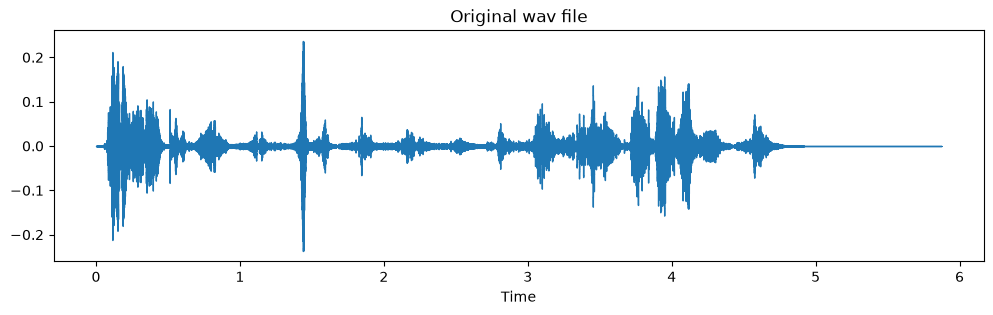

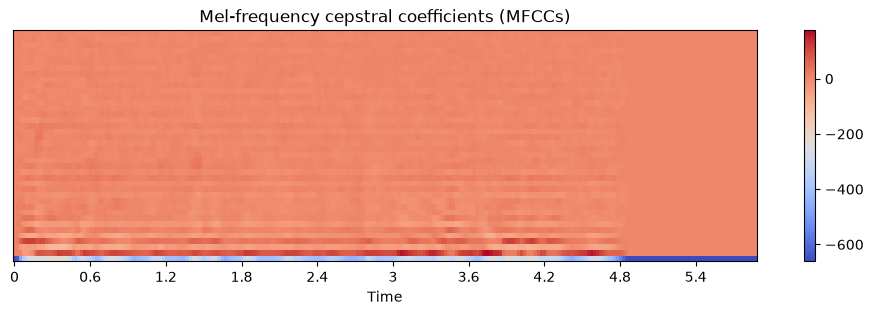

In [3]:
data_example, sampling_rate = librosa.load(sample_file)

fig1 = plt.figure(figsize=(12, 3))
librosa.display.waveshow(data_example, sr=sampling_rate)
plt.title('Original wav file')

fig2 = plt.figure(figsize=(12, 3))
mfcc = librosa.feature.mfcc(y=data_example, sr=sampling_rate, n_mfcc=40)
librosa.display.specshow(mfcc, sr=sampling_rate, x_axis='time')
plt.colorbar()
plt.title('Mel-frequency cepstral coefficients (MFCCs)');

## Part 2: Fake Audio Detection
In this step, we will build a neural network based classifier to separate synthetic audio files from real ones. We will extract features such as mel spectogram, fourier transforms etc from audio files and train the neural network to build a classification model

#### Dataset preparation

In [4]:
synthetic_file_list = os.listdir('data/cloned_audio/')
synthetic_df = pd.DataFrame([f"data/cloned_audio/{i}" for i in synthetic_file_list], columns=['files'])
synthetic_df['y'] = 0
print(synthetic_df)


real_file_list = os.listdir('data/real_audio/')
real_df = pd.DataFrame([f"data/real_audio/{i}" for i in real_file_list], columns=['files'])
real_df['y'] = 1
print(real_df)

df = pd.concat([synthetic_df, real_df], axis=0, ignore_index=True)
print(df.shape)
df.head()

                           files  y
0    data/cloned_audio/MDNS0.wav  0
1    data/cloned_audio/MDRM0.wav  0
2    data/cloned_audio/FLAC0.wav  0
3    data/cloned_audio/MAHH0.wav  0
4    data/cloned_audio/FCYL0.wav  0
..                           ... ..
295  data/cloned_audio/MDEM0.wav  0
296  data/cloned_audio/MCLK0.wav  0
297  data/cloned_audio/FSCN0.wav  0
298  data/cloned_audio/FLHD0.wav  0
299  data/cloned_audio/FSMA0.wav  0

[300 rows x 2 columns]
                                    files  y
0      data/real_audio/84-121123-0012.wav  1
1     data/real_audio/6345-64257-0014.wav  1
2     data/real_audio/3536-23268-0024.wav  1
3    data/real_audio/1272-141231-0021.wav  1
4    data/real_audio/3853-163249-0055.wav  1
..                                    ... ..
295   data/real_audio/251-137823-0006.wav  1
296  data/real_audio/2078-142845-0014.wav  1
297   data/real_audio/652-129742-0000.wav  1
298  data/real_audio/2277-149896-0007.wav  1
299   data/real_audio/5694-64029-0027.wav  1

[30

,files,y
0,data/cloned_audio/MDNS0.wav,0
1,data/cloned_audio/MDRM0.wav,0
2,data/cloned_audio/FLAC0.wav,0
3,data/cloned_audio/MAHH0.wav,0
4,data/cloned_audio/FCYL0.wav,0


The dataset has 600 recordings: 300 synthetic and 300 real. 10% is held out for testing and 10% of the rest for validation.

In [5]:
X = df[['files']]
y = df[['y']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True, stratify=y_train)

print(f"X_train length is: {len(X_train)}, y_train length is: {len(y_train)}")
print("Training data distribution\n", y_train.value_counts())

print(f"X_test length is: {len(X_test)}, y_test length is: {len(y_test)}")
print("Test data distribution\n", y_test.value_counts())

print(f"X_val length is: {len(X_val)}, y_val length is: {len(y_val)}")
print("Test data distribution\n", y_val.value_counts())

X_train length is: 486, y_train length is: 486
Training data distribution
 y
0    243
1    243
Name: count, dtype: int64
X_test length is: 60, y_test length is: 60
Test data distribution
 y
0    30
1    30
Name: count, dtype: int64
X_val length is: 54, y_val length is: 54
Test data distribution
 y
1    27
0    27
Name: count, dtype: int64


In [6]:
train_features = functions.extract_features(X_train.files)
val_features = functions.extract_features(X_val.files)
test_features = functions.extract_features(X_test.files)

In [7]:
X_train_data = functions.concat_features(train_features)
X_val_data = functions.concat_features(val_features)
X_test_data = functions.concat_features(test_features)

In [8]:
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [9]:
print("Shape of the training data: ", X_train_data.shape)
print("Shape of the testing data: ", X_test_data.shape)

Shape of the training data:  (486, 193)
Shape of the testing data:  (60, 193)


#### Create a custom classifier
Train the neural network with the training dataset and validate it using test dataset.

In [10]:
classifier_model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu', input_shape=(193,)),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')])


classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                         loss = 'binary_crossentropy',
                         metrics=["accuracy"])

In [11]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1)

classifier_model_history = classifier_model.fit(X_train_data, y_train,
                                                epochs=1000,
                                                validation_data=(X_val_data, y_val),
                                                callbacks=[callback])

Epoch 1/1000


 1/16 ━━━━━━━━━━━━━━━━━━━━ 3:18 13s/step - accuracy: 0.4375 - loss: 1.2062

 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4643 - loss: 0.9028  

11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5199 - loss: 0.8219

15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5729 - loss: 0.7617

...

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 6.5400e-04 - val_accuracy: 0.9074 - val_loss: 0.1444


Epoch 55/1000


 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 5.9425e-04

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 6.2231e-04 - val_accuracy: 0.9074 - val_loss: 0.1442


Epoch 55: early stopping


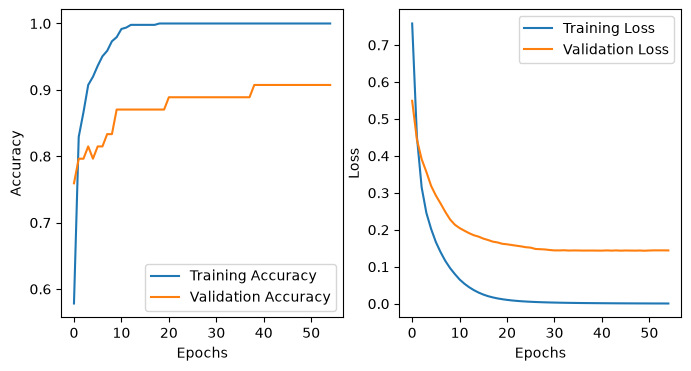

In [12]:
functions.plot_curves(classifier_model_history, epochs=len(classifier_model_history.history['loss']))

Evaluate the model on test data

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


Accuracy of the model on test data :  1.0
####################################################################################################


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



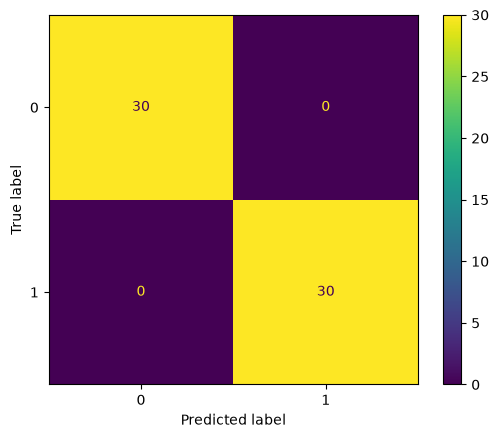

Total Synthetic recordings predicted 30
Total real recordings predicted 30


In [13]:
y_pred = classifier_model.predict(X_test_data)
y_pred = np.rint(y_pred)
y_pred = y_pred.flatten()

functions.eval_results(y_test, y_pred)